In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('clean_sets/features_extracted.csv')

features = [
    'population_density', 
    'accessibility_score', 
    'competitor_density', 
    'distance_to_main_road', 
    'distance_to_nearest_supermarket'
]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
dbscan = DBSCAN(eps=0.3, min_samples=50)
df['Cluster'] = dbscan.fit_predict(X_scaled)

valid_mask = df['Cluster'] != -1
if len(set(df.loc[valid_mask, 'Cluster'])) > 1:
    score = silhouette_score(X_scaled[valid_mask], df.loc[valid_mask, 'Cluster'])
    print(f"Silhouette Score (Valid Zones Only): {score:.4f}")
else:
    print("Not enough valid clusters to calculate score.")

print("\nPoint Distribution:")
print(df['Cluster'].value_counts().sort_index())

Silhouette Score (Valid Zones Only): 0.4624

Point Distribution:
Cluster
-1    5833
 0    1257
 1     682
 2      95
 3     236
Name: count, dtype: int64


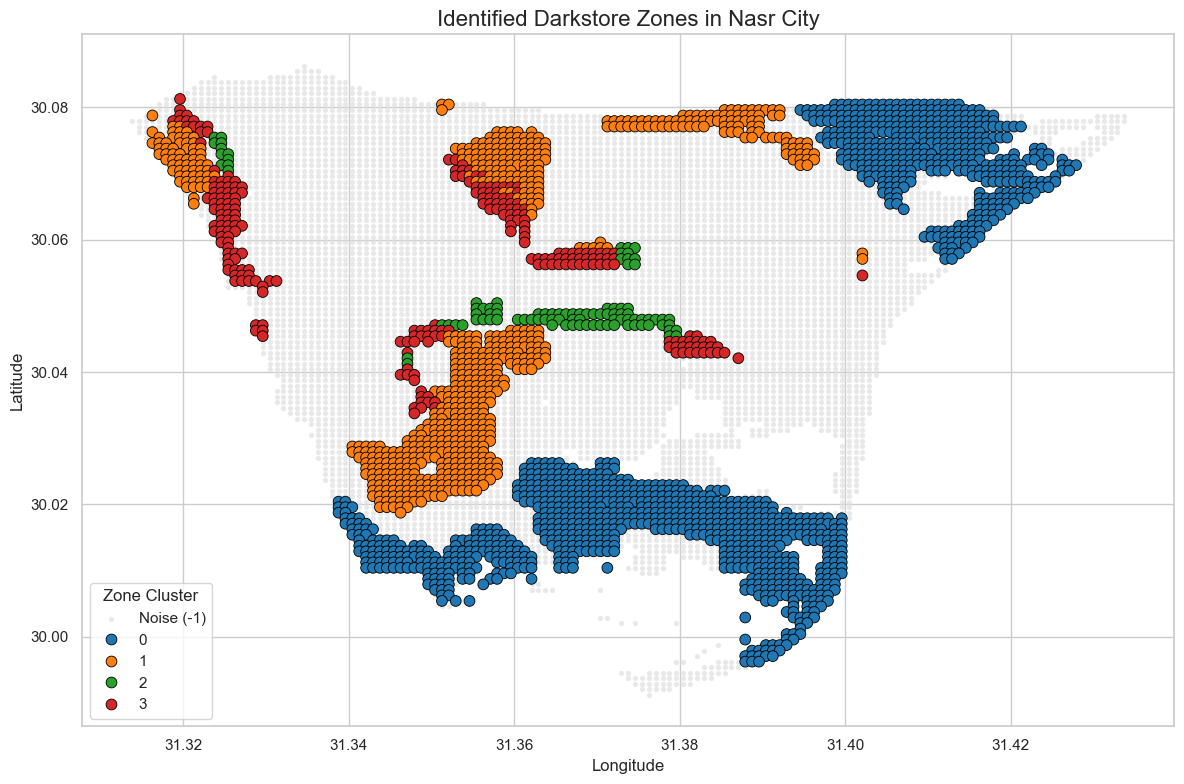

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df[df['Cluster'] == -1], x='longitude', y='latitude', 
                color='lightgrey', label='Noise (-1)', alpha=0.5, s=15)

sns.scatterplot(data=df[df['Cluster'] != -1], x='longitude', y='latitude', 
                hue='Cluster', palette='tab10', s=60, edgecolor='black')

plt.title('Identified Darkstore Zones in Nasr City', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Zone Cluster')
plt.tight_layout()
plt.show()

C:\Users\win  10\AppData\Local\Temp\ipykernel_13624\4097262990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_df, x='Cluster', y='population_density', ax=axes[0], palette='tab10')
C:\Users\win  10\AppData\Local\Temp\ipykernel_13624\4097262990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_df, x='Cluster', y='competitor_density', ax=axes[1], palette='tab10')


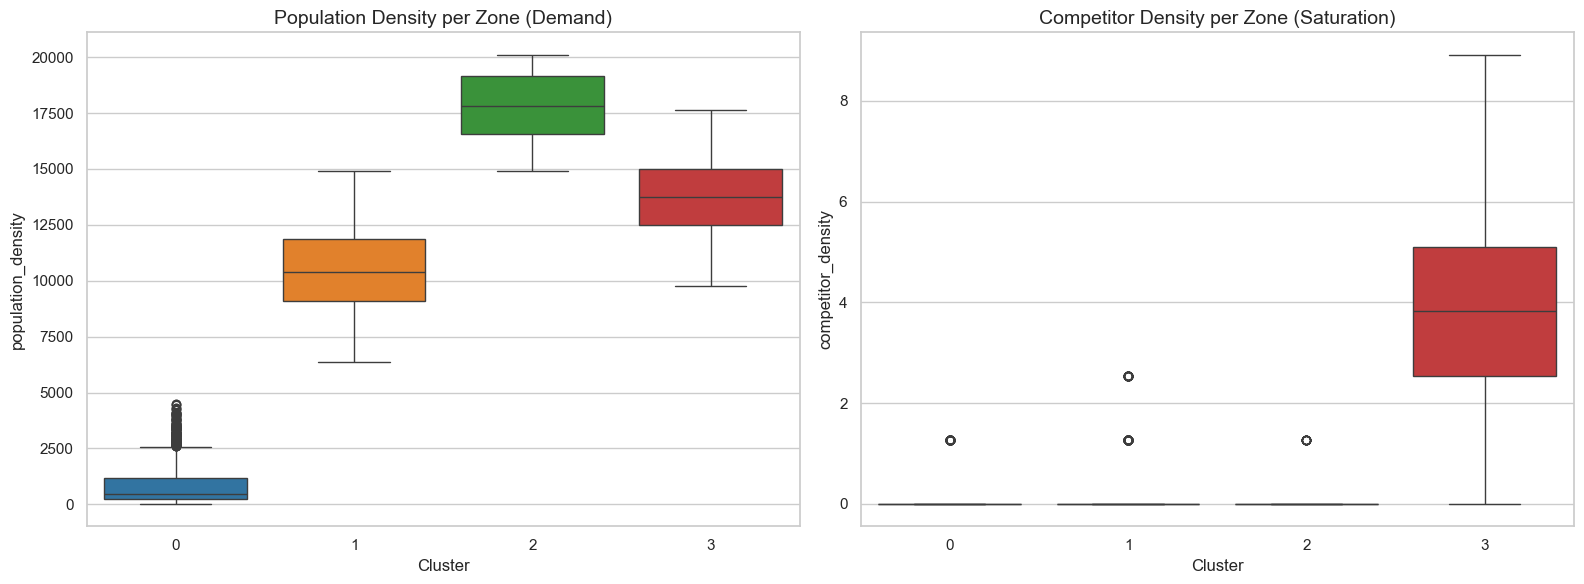


Mean feature values for valid clusters:
         population_density  accessibility_score  competitor_density  distance_to_main_road  distance_to_nearest_supermarket
Cluster                                                                                                                     
0                  916.0701               0.3398              0.0577                 0.1935                           2.3095
1                10484.3098               0.4674              0.2726                 0.1305                           1.0747
2                17725.4788               0.5850              0.1474                 0.0979                           0.6393
3                13737.1618               0.5724              4.1380                 0.0732                           0.4015


In [ ]:
valid_df = df[df['Cluster'] != -1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=valid_df, x='Cluster', y='population_density', ax=axes[0], palette='tab10')
axes[0].set_title('Population Density per Zone', fontsize=14)

sns.boxplot(data=valid_df, x='Cluster', y='competitor_density', ax=axes[1], palette='tab10')
axes[1].set_title('Competitor Density per Zone', fontsize=14)

plt.tight_layout()
plt.show()

print("\nMean feature values for valid clusters:")
print(valid_df.groupby('Cluster')[features].mean().round(4).to_string())